# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle. 

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [10]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [8]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

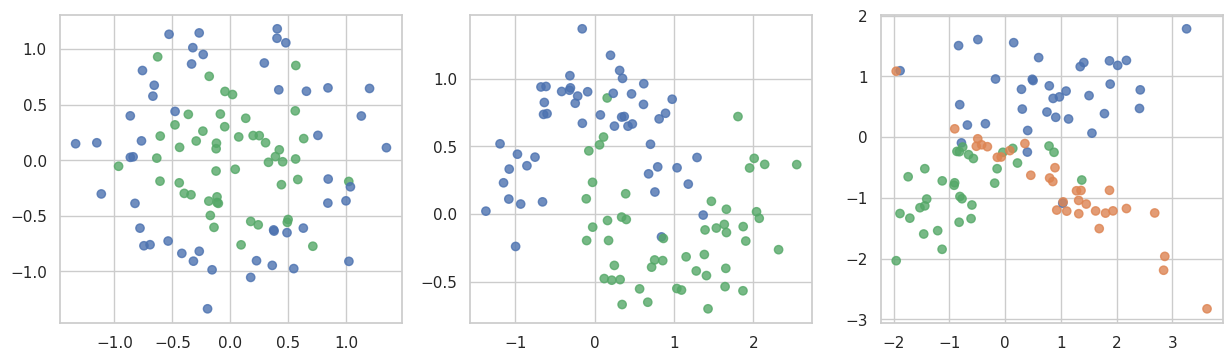

In [11]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [15]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

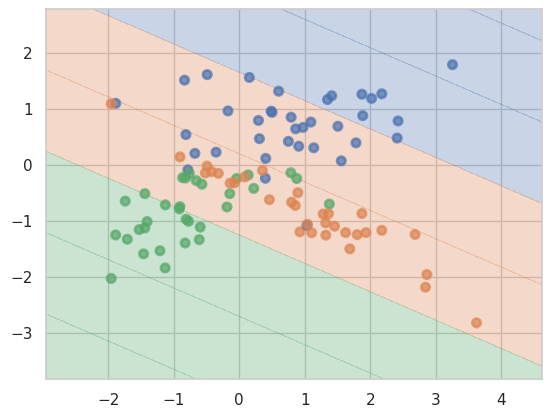

In [16]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

Dataset 1: train_acc = 1.000, test_acc = 0.733
Dataset 2: train_acc = 1.000, test_acc = 0.867
Dataset 3: train_acc = 1.000, test_acc = 0.833


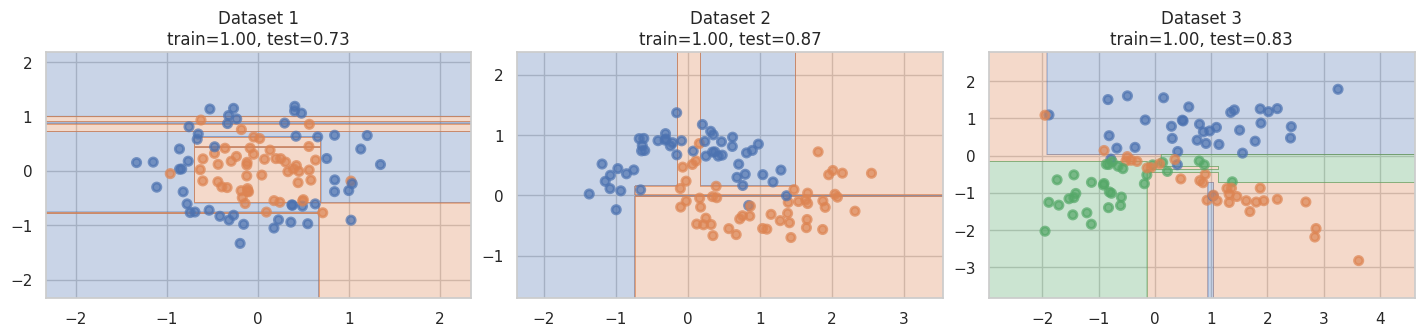

In [17]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

plt.figure(figsize=(15, 4))

for i, (X, y) in enumerate(datasets):
    # разбиение
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # обучение дерева с параметрами по умолчанию
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    # точность на train и test
    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)

    print(f"Dataset {i + 1}: train_acc = {train_acc:.3f}, test_acc = {test_acc:.3f}")

    plt.subplot(1, 3, i + 1)
    plot_surface(clf, X, y)
    plt.title(f"Dataset {i + 1}\ntrain={train_acc:.2f}, test={test_acc:.2f}")

plt.show()


__Ответ:__  
Для всех трёх датасетов дерево решений с параметрами по умолчанию полностью выучивает обучающую выборку (accuracy на train = 1.0), но на тесте качество заметно ниже (0.73, 0.87 и 0.83). Особенно сильное падение видно на первом датасете (с 1.0 до 0.73). Это означает, что деревья существенно переобучаются: без ограничений на глубину и размер листьев модель подстраивается под шум и частные особенности обучающей выборки


__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?


Dataset: circles
            default: train = 1.000, test = 0.733
        max_depth=3: train = 0.886, test = 0.733
        max_depth=5: train = 0.971, test = 0.767
 min_samples_leaf=5: train = 0.871, test = 0.900
min_samples_leaf=10: train = 0.814, test = 0.767

Dataset: moons
            default: train = 1.000, test = 0.867
        max_depth=3: train = 0.914, test = 0.933
        max_depth=5: train = 1.000, test = 0.867
 min_samples_leaf=5: train = 0.957, test = 0.733
min_samples_leaf=10: train = 0.871, test = 0.767

Dataset: classification
            default: train = 1.000, test = 0.833
        max_depth=3: train = 0.943, test = 0.867
        max_depth=5: train = 0.971, test = 0.800
 min_samples_leaf=5: train = 0.900, test = 0.700
min_samples_leaf=10: train = 0.886, test = 0.767


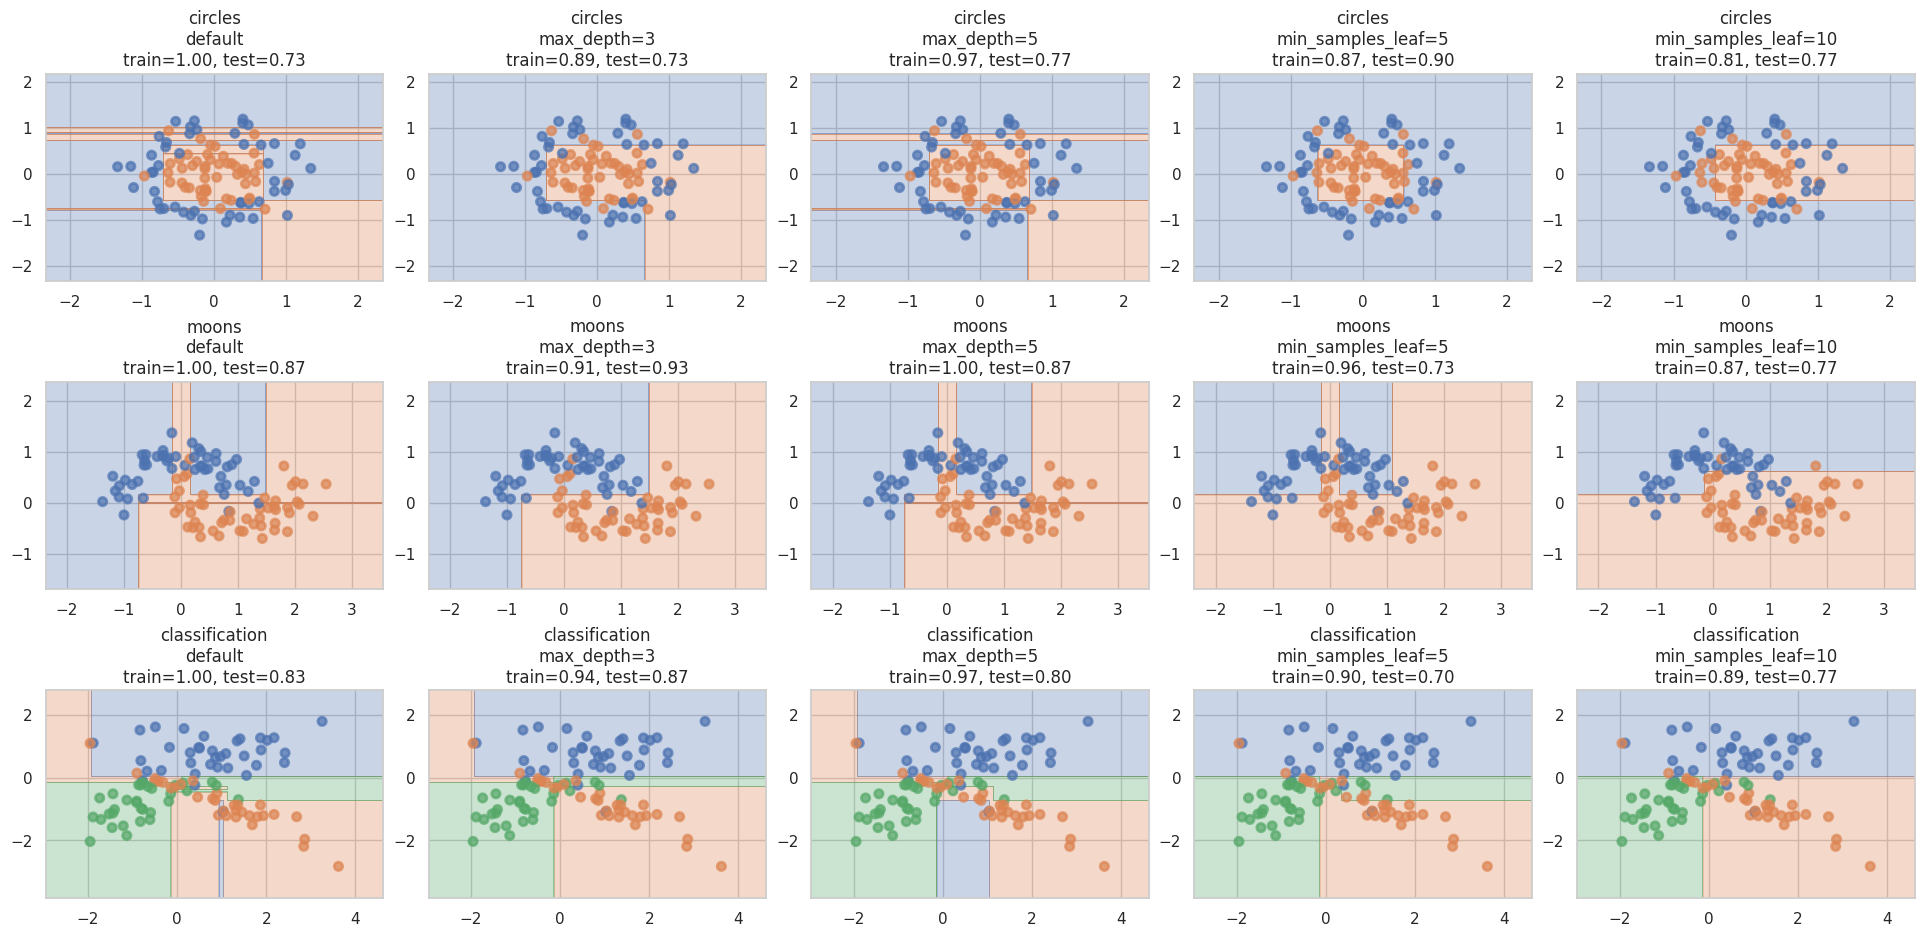

In [71]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

dataset_names = ["circles", "moons", "classification"]

# конфигурации
param_configs = [
    ("default",               {}),                     # без ограничений
    ("max_depth=3",           {"max_depth": 3}),
    ("max_depth=5",           {"max_depth": 5}),
    ("min_samples_leaf=5",    {"min_samples_leaf": 5}),
    ("min_samples_leaf=10",   {"min_samples_leaf": 10}),
]

plt.figure(figsize=(20, 10))
plot_idx = 1

for ds_idx, ((X, y), ds_name) in enumerate(zip(datasets, dataset_names)):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    print(f"\nDataset: {ds_name}")

    for cfg_name, params in param_configs:
        clf = DecisionTreeClassifier(random_state=42, **params)
        clf.fit(X_train, y_train)

        train_acc = clf.score(X_train, y_train)
        test_acc = clf.score(X_test, y_test)

        print(f"{cfg_name:>19}: train = {train_acc:.3f}, test = {test_acc:.3f}")

        plt.subplot(len(datasets), len(param_configs), plot_idx)
        plot_surface(clf, X, y)
        plt.title(f"{ds_name}\n{cfg_name}\n"
                  f"train={train_acc:.2f}, test={test_acc:.2f}")
        plot_idx += 1

plt.show()


__Ответ:__  
При добавлении регуляризации (max_depth, min_samples_leaf) разделяющая поверхность становится более гладкой, дерево перестаёт подстраиваться под шум в обучающей выборке  
При умеренных значениях гиперпараметров точность на тестовой выборке обычно улучшается, несмотря на снижение точности на обучении (снижение переобучения). При слишком сильной регуляризации (очень маленькая глубина, большие min_samples_leaf) модель начинает недообучаться, и качество падает и на train, и на test  
Изменение качества для разных датасетов разное: шумные и сложные по форме датасеты (circles, moons) более чувствительны к выбору гиперпараметров (им нужна более сложная модель для описания кривой границы), тогда как на более простом датасете make_classification уже небольшая глубина дерева даёт хорошее обобщение

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

In [20]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from hw2code import find_best_split

students = pd.read_csv("datasets/students.csv")

feature_names = students.columns[:-1]
X = students[feature_names].values
y = students.iloc[:, -1].values

thresholds_list = []
ginis_list = []

for j, name in enumerate(feature_names):
    thresholds, ginis, thr_best, gini_best = find_best_split(X[:, j], y)
    thresholds_list.append(thresholds)
    ginis_list.append(ginis)
    print(f"{name}: best_threshold={thr_best:.3f}, best_gini={gini_best:.3f}")


STG: best_threshold=0.615, best_gini=-0.454
SCG: best_threshold=0.425, best_gini=-0.465
STR: best_threshold=0.365, best_gini=-0.467
LPR: best_threshold=0.390, best_gini=-0.455
PEG: best_threshold=0.335, best_gini=-0.086


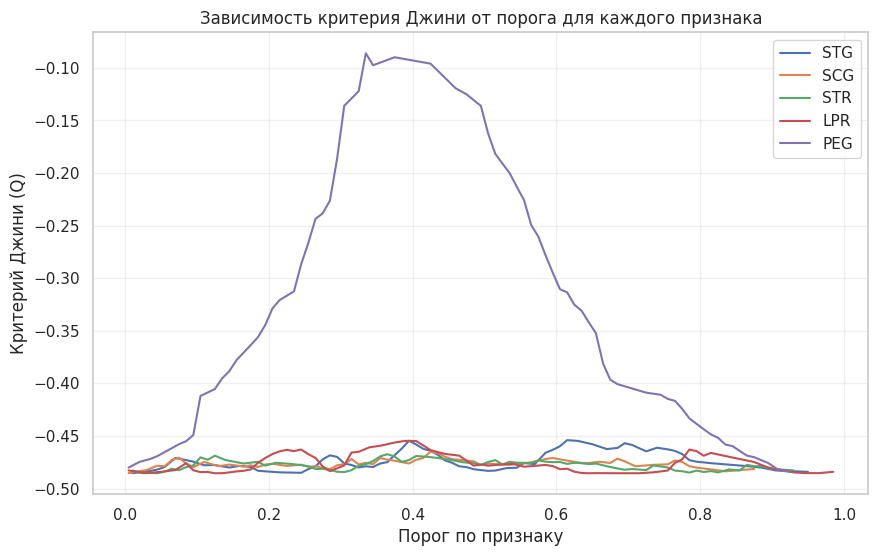

In [21]:
plt.figure(figsize=(10, 6))

for thresholds, ginis, name in zip(thresholds_list, ginis_list, feature_names):
    plt.plot(thresholds, ginis, label=name)

plt.xlabel("Порог по признаку")
plt.ylabel("Критерий Джини (Q)")
plt.title("Зависимость критерия Джини от порога для каждого признака")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


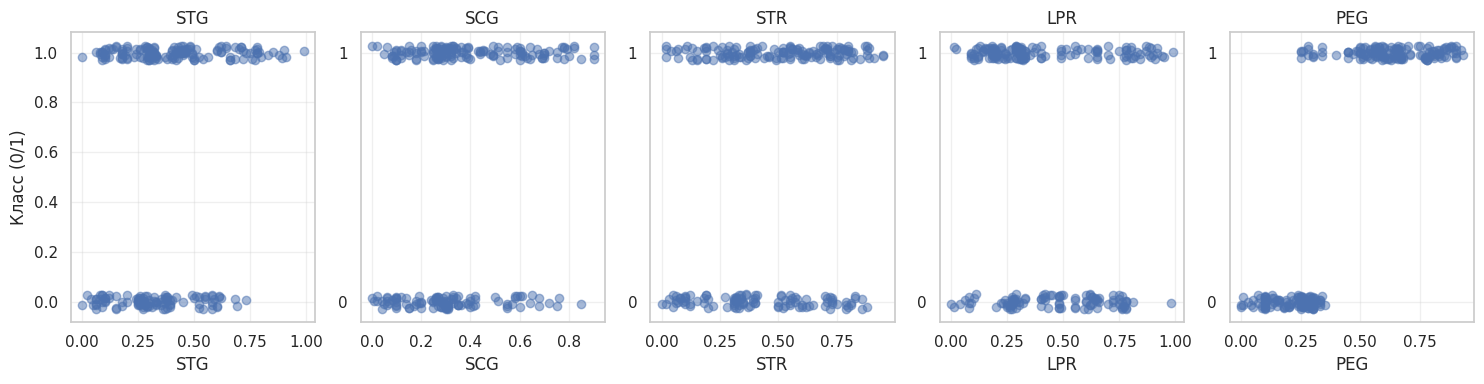

In [22]:
plt.figure(figsize=(15, 4))

for j, name in enumerate(feature_names):
    plt.subplot(1, 5, j + 1)

    y_jitter = y + np.random.uniform(-0.03, 0.03, size=len(y))

    plt.scatter(students[name], y_jitter, alpha=0.5)
    plt.xlabel(name)
    if j == 0:
        plt.ylabel("Класс (0/1)")
    else:
        plt.yticks([0, 1], ["0", "1"])

    plt.title(name)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:**  
Делить выборку на два поддерева лучше всего по признаку PEG, так как максимальное значение критерия Джини для него наибольшее (кривая Джини выше, чем у остальных признаков)  
Да, результат согласуется: именно по признаку PEG на scatter-графике лучше всего видна вертикальная граница, которая разделяет классы  
Для “хороших” признаков: кривая «порог – критерий Джини» имеет отчётливый, узкий максимум, значение критерия в этой точке близко к нулю и этот максимум заметно выше, чем остальные значения вдоль оси порогов  
Для признаков, по которым деление практически невозможно: кривая почти плоская, без ярко выраженного пика, все значения критерия Джини примерно одинаковы и далеки от нуля, то есть нет какого-то особого порога, который давал бы существенно лучшее разбиение



__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [64]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from hw2code import DecisionTree

In [65]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
df = pd.read_csv("datasets/agaricus-lepiota.data", header=None)

n_cols = df.shape[1]
df.columns = ["class"] + [f"f{i}" for i in range(1, n_cols)]

df_enc = df.copy()
for col in df_enc.columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.iloc[:, 1:].values   # признаки
y = df_enc.iloc[:, 0].values    # целевая переменная

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

feature_types = ["categorical"] * X.shape[1]

dt = DecisionTree(feature_types=feature_types)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)

def tree_depth(node):
    if node["type"] == "terminal":
        return 1
    return 1 + max(tree_depth(node["left_child"]),
                   tree_depth(node["right_child"]))

print("Tree depth:", tree_depth(dt._tree))

Test accuracy: 1.0
Tree depth: 8


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

In [66]:
ttt = pd.read_csv("datasets/tic-tac-toe-endgame.csv")

X_raw = ttt.iloc[:, :-1].copy()
y_raw = ttt.iloc[:, -1].copy()

X_enc = X_raw.copy()
for col in X_enc.columns:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_enc[col])

le_y = LabelEncoder()
y_enc = le_y.fit_transform(y_raw)

X = X_enc.values
y = y_enc

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

feature_types = ["categorical"] * X.shape[1]

Зависимость от max_depth

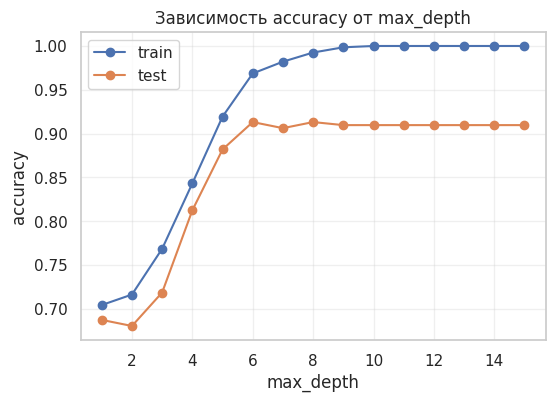

In [67]:
depths = range(1, 16)
train_acc = []
test_acc = []

for d in depths:
    dt = DecisionTree(feature_types=feature_types,
                      max_depth=d,
                      min_samples_split=None,
                      min_samples_leaf=None)
    dt.fit(X_train, y_train)
    y_tr_pred = dt.predict(X_train)
    y_te_pred = dt.predict(X_test)

    train_acc.append(accuracy_score(y_train, y_tr_pred))
    test_acc.append(accuracy_score(y_test, y_te_pred))

plt.figure(figsize=(6, 4))
plt.plot(depths, train_acc, marker="o", label="train")
plt.plot(depths, test_acc, marker="o", label="test")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Зависимость accuracy от max_depth")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Зависимость от min_samples_split

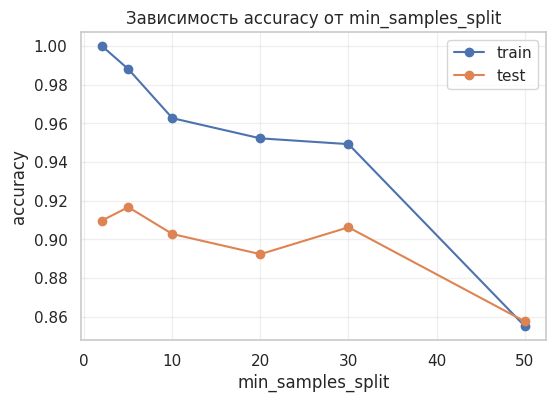

In [68]:
min_samples_split_values = [2, 5, 10, 20, 30, 50]
train_acc_split = []
test_acc_split = []

for m in min_samples_split_values:
    dt = DecisionTree(feature_types=feature_types,
                      max_depth=None,
                      min_samples_split=m,
                      min_samples_leaf=None)
    dt.fit(X_train, y_train)
    y_tr_pred = dt.predict(X_train)
    y_te_pred = dt.predict(X_test)

    train_acc_split.append(accuracy_score(y_train, y_tr_pred))
    test_acc_split.append(accuracy_score(y_test, y_te_pred))

plt.figure(figsize=(6, 4))
plt.plot(min_samples_split_values, train_acc_split, marker="o", label="train")
plt.plot(min_samples_split_values, test_acc_split, marker="o", label="test")
plt.xlabel("min_samples_split")
plt.ylabel("accuracy")
plt.title("Зависимость accuracy от min_samples_split")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Зависимость от min_samples_leaf

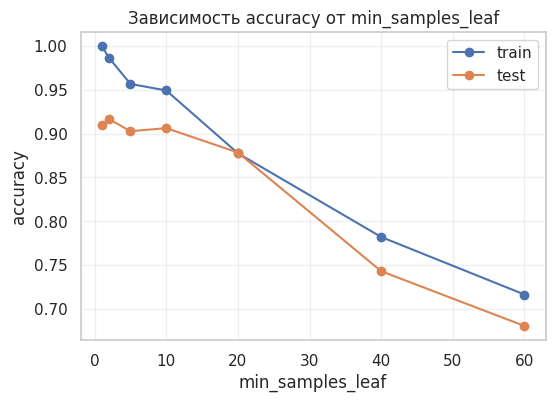

In [69]:
min_samples_leaf_values  = [1, 2, 5, 10, 20, 40, 60]
train_acc_leaf = []
test_acc_leaf = []

for m in min_samples_leaf_values:
    dt = DecisionTree(feature_types=feature_types,
                      max_depth=None,
                      min_samples_split=None,
                      min_samples_leaf=m)
    dt.fit(X_train, y_train)
    y_tr_pred = dt.predict(X_train)
    y_te_pred = dt.predict(X_test)

    train_acc_leaf.append(accuracy_score(y_train, y_tr_pred))
    test_acc_leaf.append(accuracy_score(y_test, y_te_pred))

plt.figure(figsize=(6, 4))
plt.plot(min_samples_leaf_values, train_acc_leaf, marker="o", label="train")
plt.plot(min_samples_leaf_values, test_acc_leaf, marker="o", label="test")
plt.xlabel("min_samples_leaf")
plt.ylabel("accuracy")
plt.title("Зависимость accuracy от min_samples_leaf")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [74]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, ClassifierMixin


In [73]:
mush = pd.read_csv("datasets/agaricus-lepiota.data", header=None)

mush_enc = mush.copy()
for col in mush_enc.columns:
    le = LabelEncoder()
    mush_enc[col] = le.fit_transform(mush_enc[col])

X_mush = mush_enc.iloc[:, 1:].values
y_mush = mush_enc.iloc[:, 0].values


ttt = pd.read_csv("datasets/tic-tac-toe-endgame.csv")  

X_ttt_raw = ttt.iloc[:, :-1].copy()
y_ttt_raw = ttt.iloc[:, -1].copy()

X_ttt_enc = X_ttt_raw.copy()
for col in X_ttt_enc.columns:
    le = LabelEncoder()
    X_ttt_enc[col] = le.fit_transform(X_ttt_enc[col])

le_y_ttt = LabelEncoder()
y_ttt_enc = le_y_ttt.fit_transform(y_ttt_raw)

X_ttt = X_ttt_enc.values
y_ttt = y_ttt_enc


cars = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data", header=None)   

X_cars_raw = cars.iloc[:, :-1].copy()
y_cars_raw = cars.iloc[:, -1].copy()

y_cars = y_cars_raw.map(lambda v: 0 if v in ["unacc", "acc"] else 1).values

X_cars_enc = X_cars_raw.copy()
for col in X_cars_enc.columns:
    le = LabelEncoder()
    X_cars_enc[col] = le.fit_transform(X_cars_enc[col])

X_cars = X_cars_enc.values


nur = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/nursery/nursery.data", header=None)

X_nur_raw = nur.iloc[:, :-1].copy()
y_nur_raw = nur.iloc[:, -1].copy()

y_nur = y_nur_raw.map(
    lambda v: 0 if v in ["not_recom", "recommend"] else 1
).values

X_nur_enc = X_nur_raw.copy()
for col in X_nur_enc.columns:
    le = LabelEncoder()
    X_nur_enc[col] = le.fit_transform(X_nur_enc[col])

X_nur = X_nur_enc.values


In [77]:
# чтобы потом удобно было крутить циклом
datasets = {
    "mushrooms": (X_mush, y_mush),
    "tic-tac-toe": (X_ttt, y_ttt),
    "cars": (X_cars, y_cars),
    "nursery": (X_nur, y_nur),
}

In [78]:
# обертка для нашего дереве
class MyDecisionTree(BaseEstimator, ClassifierMixin):
    def __init__(self, feature_types, max_depth=None,
                 min_samples_split=None, min_samples_leaf=None):
        self.feature_types = feature_types
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self._model = None

    def fit(self, X, y):
        self._model = DecisionTree(
            feature_types=self.feature_types,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            min_samples_leaf=self.min_samples_leaf,
        )
        self._model.fit(X, y)
        return self

    def predict(self, X):
        return self._model.predict(X)


In [81]:
scoring = make_scorer(accuracy_score)
results = {}

for name, (X, y) in datasets.items():
    print(f"{name}")
    n_features = X.shape[1]

    # вещественные признаки
    feat_real = ["real"] * n_features
    clf_real = MyDecisionTree(feature_types=feat_real)
    acc_real = cross_val_score(clf_real, X, y, cv=10, scoring=scoring).mean()
    print("  our DT (real):         ", acc_real)

    # категориальные признаки
    feat_cat = ["categorical"] * n_features
    clf_cat = MyDecisionTree(feature_types=feat_cat)
    acc_cat = cross_val_score(clf_cat, X, y, cv=10, scoring=scoring).mean()
    print("  our DT (categorical):  ", acc_cat)

    # real + one-hot encoding
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    X_ohe = ohe.fit_transform(X)
    feat_real_ohe = ["real"] * X_ohe.shape[1]
    clf_ohe = MyDecisionTree(feature_types=feat_real_ohe)
    acc_ohe = cross_val_score(clf_ohe, X_ohe, y, cv=10, scoring=scoring).mean()
    print("  our DT (real + OHE):   ", acc_ohe)

    # sklearn DecisionTreeClassifier
    sk_clf = DecisionTreeClassifier(random_state=42)
    acc_sk = cross_val_score(sk_clf, X, y, cv=10, scoring=scoring).mean()
    print("  sklearn DT:            ", acc_sk)

    results[name] = {
        "our_real": acc_real,
        "our_categorical": acc_cat,
        "our_real_OHE": acc_ohe,
        "sklearn_DT": acc_sk,
    }

mushrooms
  our DT (real):          0.9992610837438424
  our DT (categorical):   1.0
  our DT (real + OHE):    0.9996305418719211
  sklearn DT:             0.9603836062991171
tic-tac-toe
  our DT (real):          0.4675328947368421
  our DT (categorical):   0.5414583333333333
  our DT (real + OHE):    0.5435745614035088
  sklearn DT:             0.7716776315789474
cars
  our DT (real):          0.9426468611372497
  our DT (categorical):   0.9675460411345611
  our DT (real + OHE):    0.919495227853206
  sklearn DT:             0.9427073531388628
nursery
  our DT (real):          0.9996913580246914
  our DT (categorical):   0.9998456790123458
  our DT (real + OHE):    0.999537037037037
  sklearn DT:             0.9996913580246914


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**  
Одинаково ли ранжируются алгоритмы?

Нет. На разных датасетах лучшим может быть разный вариант:  
- на mushrooms почти все модели дают accuracy примерно 1
- на tic-tac-toe хорошо работают категориальное дерево и OHE
- на cars, nursery особенно важна корректная работа с категориальными признаками (categorical и OHE обычно лучше, чем просто вещественные)
    
Разница связана с тем, как закодированы признаки и насколько естественно дерево может по ним делить классы  

Почему так происходит?  
- Вариант «все признаки вещественные после LabelEncoder» навязывает искусственный порядок категориям, следовательно иногда портит разбиения
- Вариант "categorical" и вариант с one-hot лучше отражают природу признаков, следовательно дерево строит более осмысленные сплиты
- DecisionTreeClassifier из sklearn обычно даёт базу очень высокого качества за счёт отлаженной реализации и настроек  

Есть ли случайность и можно ли на неё повлиять?

Да, есть.
- случайность в разбиении на фолды (cross_val_score)
- случайность в DecisionTreeClassifier, если не фиксировать random_state  

Влияние:  
- фиксировать random_state у моделей и в кросс-валидации результаты становятся воспроизводимыми
- усреднять качество по большему числу фолдов - уменьшает дисперсию оценки
- подбирать гиперпараметры (max_depth, min_samples_*) по кросс-валидации, следовательно можно немного улучшить качество и снизить переобучение

Вставьте что угодно, описывающее ваши впечатления от этого задания:

In [ ]:
интересненько